<a href="https://colab.research.google.com/github/rudrapal0110-sketch/ASSIGNMENT-2-EXCEL../blob/main/Logistic_Regression_(Loan_Approval_Prediction).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving loan_approval.xlsx to loan_approval.xlsx


Q1. Data Loading & Understanding

a) Load the dataset into Python.
b) Display the first 5 rows.
c) Check the shape of the dataset.
d) Display the data types of each column.


In [5]:
# Load the dataset
df = pd.read_excel("loan_approval.xlsx")

In [ ]:
# Display the first 5 rows
print(df.head())

              name              city  income  credit_score  loan_amount  \
0     Allison Hill         East Jill  113810           389        39698   
1     Brandon Hall     New Jamesside   44592           729        15446   
2     Rhonda Smith      Lake Roberto   33278           584        11189   
3  Gabrielle Davis  West Melanieview  127196           344        48823   
4     Valerie Gray         Mariastad   66048           496        47174   

   years_employed  points  loan_approved  
0              27      50          False  
1              28      55          False  
2              13      45          False  
3              29      50          False  
4               4      25          False  


In [ ]:
 # Check the shape of the dataset
 print(df.shape)

(2000, 8)


In [ ]:
#Display the data types of each column
print(df.dtypes)

name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object


Q2. Data Cleaning

a) Check for missing values in the dataset.
b) Handle missing values appropriately.
c) Identify categorical columns present in the dataset.

In [ ]:
#  Check for missing values in the dataset
print(df.isnull().sum())

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64


In [ ]:
# Handle missing values appropriately
 # Numerical Columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical Columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)



/tmp/ipykernel_2312/1469490922.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_2312/1469490922.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [6]:
# Identify Categorical Columns
cat_cols = df.select_dtypes(include='object').columns

print(cat_cols)

Index(['name', 'city'], dtype='object')


Q4. Outlier Detection and Treatment

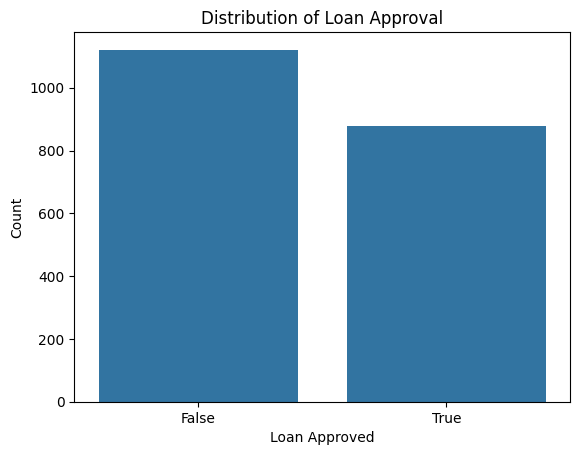

In [7]:
# Plot the distribution of the target variable.
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='loan_approved', data=df)

plt.title("Distribution of Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Count")

plt.show()

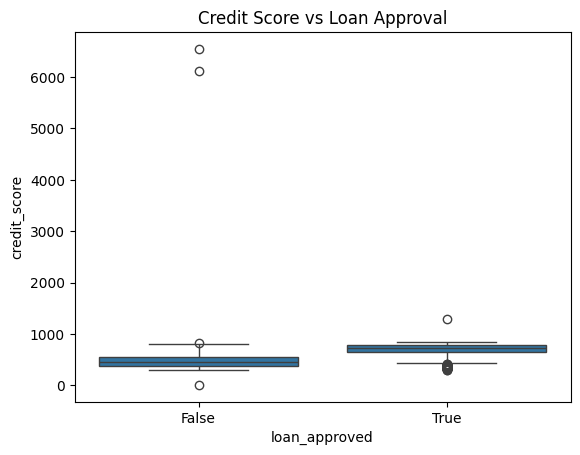

In [8]:
# Analyze the relationship between one numerical feature and the target variable.
sns.boxplot(x='loan_approved', y='credit_score', data=df)

plt.title("Credit Score vs Loan Approval")

plt.show()

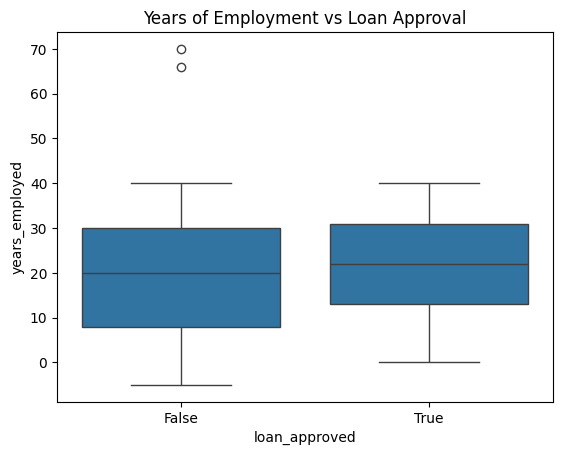

In [9]:
# Analyze the relationship between Years of Employment and the target variable
sns.boxplot(x='loan_approved', y='years_employed', data=df)

plt.title("Years of Employment vs Loan Approval")

plt.show()

In [ ]:
# Q4. Outlier Detection and Treatment

In [10]:
# Detect outliers in numerical columns using the IQR method.
numerical_cols = [
    'income',
    'credit_score',
    'loan_amount',
    'years_employed',
    'points'
]

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, ":", len(outliers), "outliers")

income : 0 outliers
credit_score : 3 outliers
loan_amount : 0 outliers
years_employed : 2 outliers
points : 0 outliers


In [14]:
# Treat outliers using capping techniques.
for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)
    print(col, ":", len(outliers), "outliers")

income : 0 outliers
credit_score : 0 outliers
loan_amount : 0 outliers
years_employed : 0 outliers
points : 0 outliers


In [ ]:
# Q5. Convert target variables into numerical format suitable for model building and drop unnecessary columns.

In [15]:
df['loan_approved'] = df['loan_approved'].astype(int)

df.drop(['name', 'city'], axis=1, inplace=True)

df.head()

,income,credit_score,loan_amount,years_employed,points,loan_approved
0,113810,389.0,39698,27.0,50,0
1,44592,729.0,15446,28.0,55,0
2,33278,584.0,11189,13.0,45,0
3,127196,344.0,48823,29.0,50,0
4,66048,496.0,47174,4.0,25,0


In [17]:
# Q6. Feature Selection and Data Splitting
# a) Separate independent variables (X) and dependent variable (y).
X = df.drop('loan_approved', axis=1)

y = df['loan_approved']

In [19]:
# b) Split the dataset into training and testing sets.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [20]:
# Q7. Apply feature scaling to the dataset using StandardScaler.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
# Q8. Logistic Regression Model Building
# a) Train a Logistic Regression model.
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [22]:
# b) Predict the output for test data.
y_pred = model.predict(X_test)

[[217   0]
 [  0 183]]


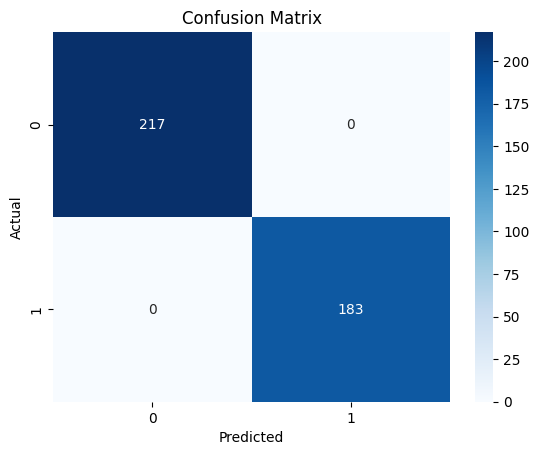

In [24]:
# Q9. Model Evaluation – Confusion Matrix
# a) Generate the confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [25]:
# b) Interpret the results
from sklearn.metrics import classification_report, accuracy_score

print(classification_report(y_test, y_pred))

print("Accuracy Score:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       217
           1       1.00      1.00      1.00       183

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

Accuracy Score: 1.0


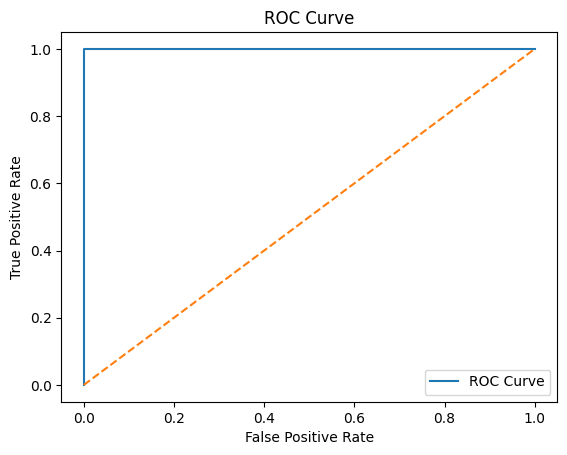

In [26]:
# Q10. Model Evaluation – ROC Curve & AUC
# a) Plot the ROC curve.
from sklearn.metrics import roc_curve

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [27]:
# b) Calculate the AUC score.
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 1.0
